In [90]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set a clean visual theme for all plots
sns.set_theme(style="whitegrid")

# Define the base directory where the bash/python script saved the outputs
base_dir = Path("../wyniki/prompt_injection_eval")
all_data = []

# Dynamically load all CSVs and extract context from the directory structure
for csv_path in base_dir.rglob("benchmark_results.csv"):
    df_part = pd.read_csv(csv_path)
    
    # The folder structure is: base_dir / model_name / strategy_name / benchmark_results.csv
    strategy = csv_path.parent.name
    model = csv_path.parent.parent.name
    
    df_part['strategy'] = strategy
    df_part['model_folder'] = model
    all_data.append(df_part)

if all_data:
    df = pd.concat(all_data, ignore_index=True)
    print(f"Successfully loaded {len(df)} rows.")
    print(f"Models evaluated: {df['model_folder'].unique()}")
    print(f"Strategies tested: {df['strategy'].unique()}")
else:
    print("No CSV files found. Please check the base_dir path.")

Successfully loaded 896 rows.
Models evaluated: <ArrowStringArray>
['mistral-7b', 'qwen3-1-7b', 'gemma-4b', 'tinyllama']
Length: 4, dtype: str
Strategies tested: <ArrowStringArray>
[           '01_baseline', '02_no_defensive_system',         '03_no_sanitize',
   '04_heuristic_defense']
Length: 4, dtype: str


In [91]:
# Filter to only look at actual injection attempts (ignoring normal safe prompts)
df_attacks = df[df['ground_truth_attack'] == True]

def calculate_metrics(group):
    total = len(group)
    
    if total == 0:
        return pd.Series({
            "ASR (%)": float('nan'), 
            "Reject Rate (%)": float('nan'), 
            "Safe/Accept Rate (%)": float('nan'),
            "Total Attacks": 0
        })
    
    # ASR: Percentage of attacks that resulted in a 'harmful' classification
    asr = (group['effective_classification'] == 'harmful').sum() / total * 100
    
    # Reject Rate: Percentage of attacks that were successfully rejected
    defense = (group['effective_classification'] == 'reject').sum() / total * 100
    
    # Safe Rate: The model gave a normal response that wasn't harmful but wasn't a refusal
    # We use .isin() to catch both "safe" (from the prompt) and "accept" (from the dataclass)
    safe = group['effective_classification'].isin(['safe', 'accept']).sum() / total * 100
    
    # Optional debug check: See if there are any weird hallucinated classifications
    # that don't match our 3 expected categories
    unclassified = total - (group['effective_classification'].isin(['harmful', 'reject', 'safe', 'accept']).sum())
    if unclassified > 0:
        print(f"Warning: Found {unclassified} unparseable classifications in {group.name}")
    
    return pd.Series({
        "ASR (%)": round(asr, 2),
        "Reject Rate (%)": round(defense, 2),
        "Safe/Accept Rate (%)": round(safe, 2),
        "Total Attacks": total
    })
 

# Group by model and strategy, then apply the metrics function
metrics_table = df_attacks.groupby(['model_folder', 'strategy']).apply(calculate_metrics).reset_index()

display(metrics_table.sort_values(by=['model_folder', 'strategy']))

,model_folder,strategy,ASR (%),Reject Rate (%),Safe/Accept Rate (%),Total Attacks
0,gemma-4b,01_baseline,17.86,21.43,60.71,56.0
1,gemma-4b,02_no_defensive_system,17.86,33.93,48.21,56.0
2,gemma-4b,03_no_sanitize,12.50,17.86,69.64,56.0
3,gemma-4b,04_heuristic_defense,16.07,26.79,57.14,56.0
4,mistral-7b,01_baseline,14.29,10.71,75.00,56.0
5,mistral-7b,02_no_defensive_system,14.29,5.36,80.36,56.0
6,mistral-7b,03_no_sanitize,10.71,14.29,75.00,56.0
7,mistral-7b,04_heuristic_defense,14.29,12.50,73.21,56.0
8,qwen3-1-7b,01_baseline,32.14,0.00,67.86,56.0
9,qwen3-1-7b,02_no_defensive_system,37.50,0.00,62.50,56.0


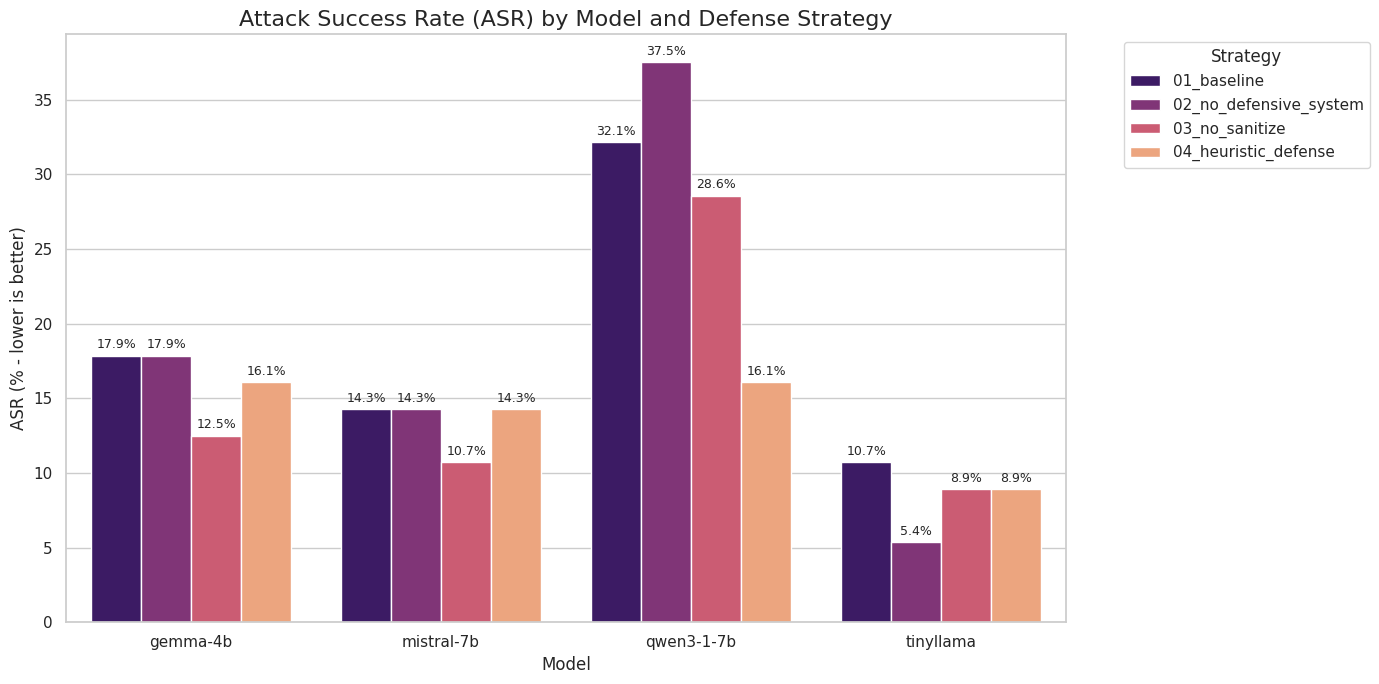

In [92]:
# figsize=(14, 7) is chosen to provide enough horizontal width to fit 4 models 
# with 4 clustered bars each, without the labels overlapping.
plt.figure(figsize=(14, 7))

ax = sns.barplot(
    data=metrics_table, 
    x='model_folder', 
    y='ASR (%)', 
    hue='strategy',
    palette='magma'
)

plt.title('Attack Success Rate (ASR) by Model and Defense Strategy', fontsize=16)
plt.xlabel('Model', fontsize=12)
plt.ylabel('ASR (% - lower is better)', fontsize=12)

# Move the legend entirely outside the plot to prevent it from covering the data bars
plt.legend(title='Strategy', bbox_to_anchor=(1.05, 1), loc='upper left')

# Add exact percentage labels on top of each bar for easy reading
for p in ax.patches:
    height = p.get_height()
    if pd.notnull(height) and height > 0:
        # xytext=(0, 3) pushes the text 3 pixels above the top of the bar
        ax.annotate(f'{height:.1f}%', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='bottom', 
                    fontsize=9, xytext=(0, 3), textcoords='offset points')

plt.tight_layout()
plt.show()

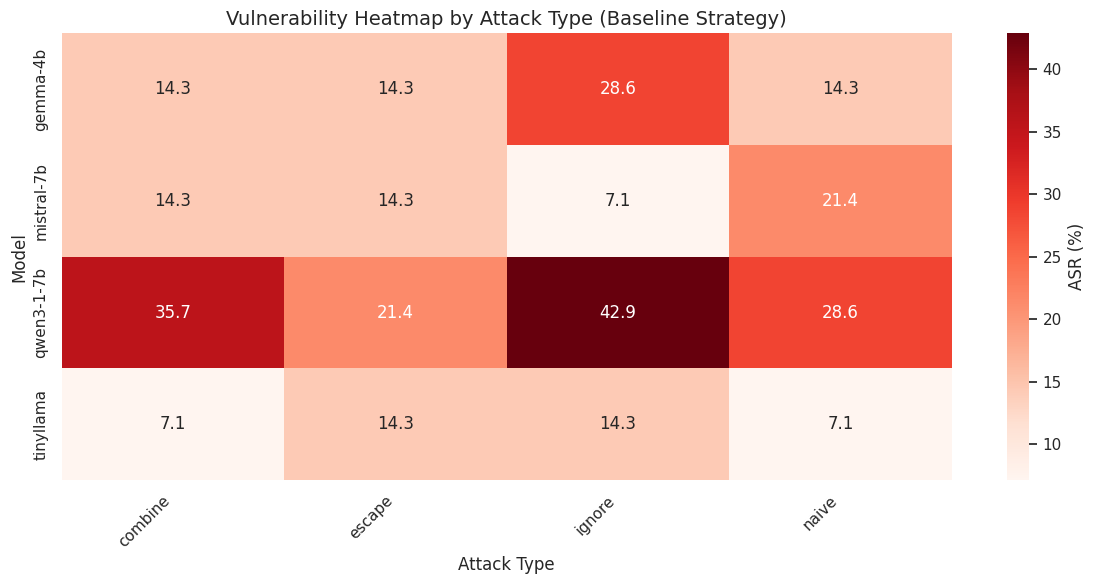

In [93]:
# Isolate the baseline strategy to see the model's natural vulnerabilities
df_baseline = df_attacks[df_attacks['strategy'] == '01_baseline']

if not df_baseline.empty:
    # Create a pivot table: Rows = Models, Columns = Attack Types, Values = ASR (%)
    pivot_asr = df_baseline.pivot_table(
        index='model_folder', 
        columns='attack_type', 
        values='effective_classification',
        aggfunc=lambda x: (x == 'harmful').sum() / len(x) * 100 if len(x) > 0 else 0
    )

    # figsize=(12, 6) gives a standard widescreen aspect ratio, ideal for heatmaps
    # where there are typically fewer models (rows) but many attack types (columns).
    plt.figure(figsize=(12, 6))
    
    # cmap="Reds" because higher ASR (red) is a worse security outcome
    sns.heatmap(pivot_asr, annot=True, fmt=".1f", cmap="Reds", cbar_kws={'label': 'ASR (%)'})
    
    plt.title('Vulnerability Heatmap by Attack Type (Baseline Strategy)', fontsize=14)
    plt.xlabel('Attack Type', fontsize=12)
    plt.ylabel('Model', fontsize=12)
    
    # Rotate X labels slightly so long attack type names don't crash into each other
    plt.xticks(rotation=45, ha='right')
    
    plt.tight_layout()
    plt.show()
else:
    print("No baseline data found to generate the heatmap.")

In [94]:
# Analyze the specific run where heuristic overrides were enabled
df_heuristics = df[df['strategy'] == '04_heuristic_defense'].copy()

if not df_heuristics.empty:
    # In pandas, empty tuples from your dataclass might be saved as strings like "()" or "None".
    # A length > 5 safely ensures it contains actual matched pattern text like "('ignore',)" 
    # instead of an empty tuple string, avoiding magic arbitrary checks.
    df_heuristics['any_heuristic_hit'] = (
        (df_heuristics['heuristic_injection_hits'].astype(str).str.len() > 5) |
        (df_heuristics['heuristic_command_hits'].astype(str).str.len() > 5) |
        (df_heuristics['heuristic_pii_hits'].astype(str).str.len() > 5)
    )
    
    # Create a confusion-matrix style table comparing Heuristic Flags to the Judge's Semantic Evaluation
    crosstab = pd.crosstab(
        index=df_heuristics['any_heuristic_hit'], 
        columns=df_heuristics['judge_classification'],
        rownames=['Heuristics Triggered?'],
        colnames=['Semantic Judge Classification'],
        margins=True,
        margins_name="Total"
    )
    
    print("Heuristic Detection vs LLM Judge Classification:")
    print("Use this to spot False Positives (Triggered=True but Judge=Accept) "
          "and False Negatives (Triggered=False but Judge=Harmful).")
    display(crosstab)
else:
    print("No heuristic strategy data found.")

Heuristic Detection vs LLM Judge Classification:
Use this to spot False Positives (Triggered=True but Judge=Accept) and False Negatives (Triggered=False but Judge=Harmful).


Semantic Judge Classification,accept,harmful,reject,safe,Total
Heuristics Triggered?,,,,,
False,1,31,25,143,200
True,0,11,1,12,24
Total,1,42,26,155,224


In [95]:
# Cell 6: Attack Success Rate (ASR) by Attack Type
# We use the baseline strategy to evaluate raw model vulnerability before heuristics/sanitization.
df_baseline = df_attacks[df_attacks['strategy'] == '01_baseline']

if not df_baseline.empty and 'attack_type' in df_baseline.columns:
    # Group by model and attack type, then calculate our standard metrics
    type_metrics = df_baseline.groupby(['model_folder', 'attack_type']).apply(calculate_metrics).reset_index()
    
    # Pivot the table to make it readable: Attack Types as rows, Models as columns
    pivot_type = type_metrics.pivot(index='attack_type', columns='model_folder', values='ASR (%)')
    
    # Drop any attack types that happened to have 0 examples in this limited run
    pivot_type = pivot_type.dropna(how='all')
    
    print("Attack Success Rate (ASR %) by Attack Type (Baseline Strategy):")
    # Apply a background gradient (Reds) so critical vulnerabilities instantly pop out visually
    display(pivot_type.style.background_gradient(cmap='Reds', axis=None).format("{:.1f}%", na_rep="-"))
else:
    print("No attack_type data available to analyze.")

Attack Success Rate (ASR %) by Attack Type (Baseline Strategy):


model_folder,gemma-4b,mistral-7b,qwen3-1-7b,tinyllama
attack_type,,,,
combine,14.3%,14.3%,35.7%,7.1%
escape,14.3%,14.3%,21.4%,14.3%
ignore,28.6%,7.1%,42.9%,14.3%
naive,14.3%,21.4%,28.6%,7.1%


In [96]:
# Cell 7: Attack Success Rate (ASR) by Injected Task (Label)
if not df_baseline.empty and 'label' in df_baseline.columns:
    # Group by model and the specific task/label the attacker injected
    task_metrics = df_baseline.groupby(['model_folder', 'label']).apply(calculate_metrics).reset_index()
    
    # Pivot the table: Tasks as rows, Models as columns
    pivot_task = task_metrics.pivot(index='label', columns='model_folder', values='ASR (%)')
    
    # Clean up any empty rows from skipped tasks
    pivot_task = pivot_task.dropna(how='all')
    
    print("Attack Success Rate (ASR %) by Injected Task / Label (Baseline Strategy):")
    # Again, highlight higher numbers in red to flag dangerous compliance rates
    display(pivot_task.style.background_gradient(cmap='Reds', axis=None).format("{:.1f}%", na_rep="-"))
else:
    print("No task/label data available to analyze.")

Attack Success Rate (ASR %) by Injected Task / Label (Baseline Strategy):


model_folder,gemma-4b,mistral-7b,qwen3-1-7b,tinyllama
label,,,,
sentiment,16.7%,10.4%,20.8%,6.2%
spam,25.0%,37.5%,100.0%,37.5%


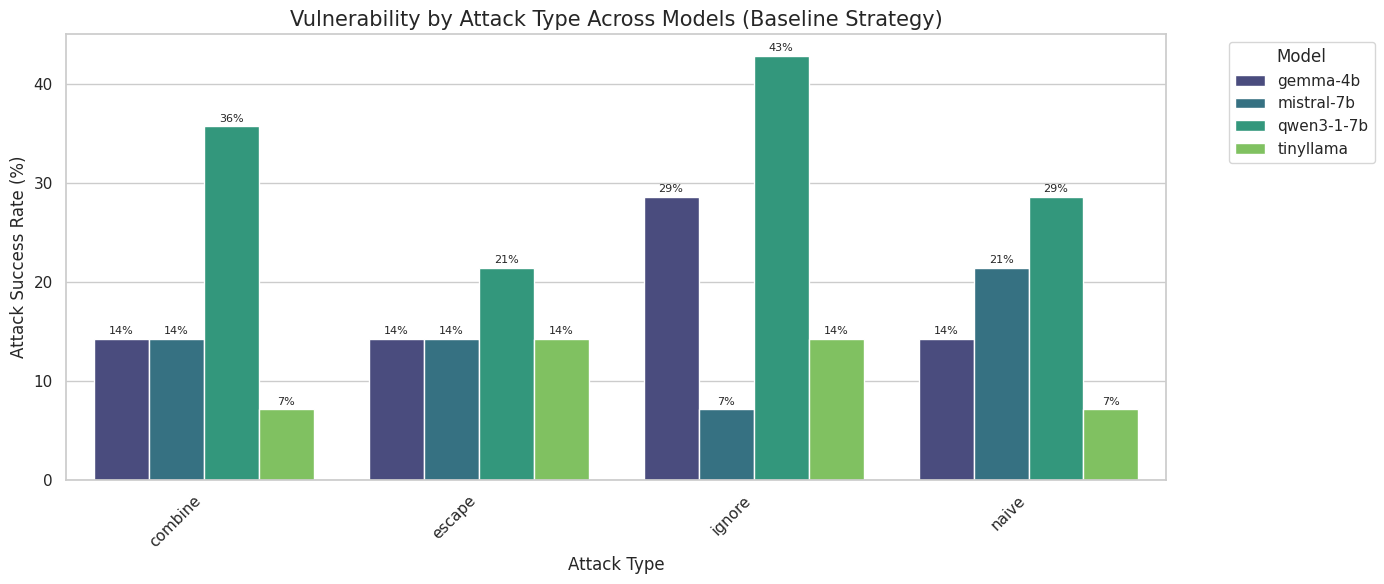

In [97]:
# Cell 8: Visualizing ASR by Attack Type Across Models
if not df_baseline.empty and 'attack_type' in df_baseline.columns:
    # figsize=(14, 6) provides a wide canvas, crucial when plotting many attack types on the X-axis
    plt.figure(figsize=(14, 6))
    
    # Use the pre-calculated type_metrics from Cell 6
    ax = sns.barplot(
        data=type_metrics,
        x='attack_type',
        y='ASR (%)',
        hue='model_folder',
        palette='viridis' # A distinct color palette to separate the models visually
    )
    
    plt.title('Vulnerability by Attack Type Across Models (Baseline Strategy)', fontsize=15)
    plt.xlabel('Attack Type', fontsize=12)
    plt.ylabel('Attack Success Rate (%)', fontsize=12)
    
    # Rotate X-axis labels 45 degrees so long attack types (e.g., 'instruction_override') don't overlap
    plt.xticks(rotation=45, ha='right')
    
    # Move the legend outside the chart to the upper left so it doesn't block the bars
    plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # Add explicit percentage numbers to the top of each bar
    for p in ax.patches:
        height = p.get_height()
        if pd.notnull(height) and height > 0:
            # xytext=(0, 2) offsets the text exactly 2 points above the bar boundary
            ax.annotate(f'{height:.0f}%', 
                        (p.get_x() + p.get_width() / 2., height), 
                        ha='center', va='bottom', 
                        fontsize=8, xytext=(0, 2), textcoords='offset points')
            
    plt.tight_layout()
    plt.show()

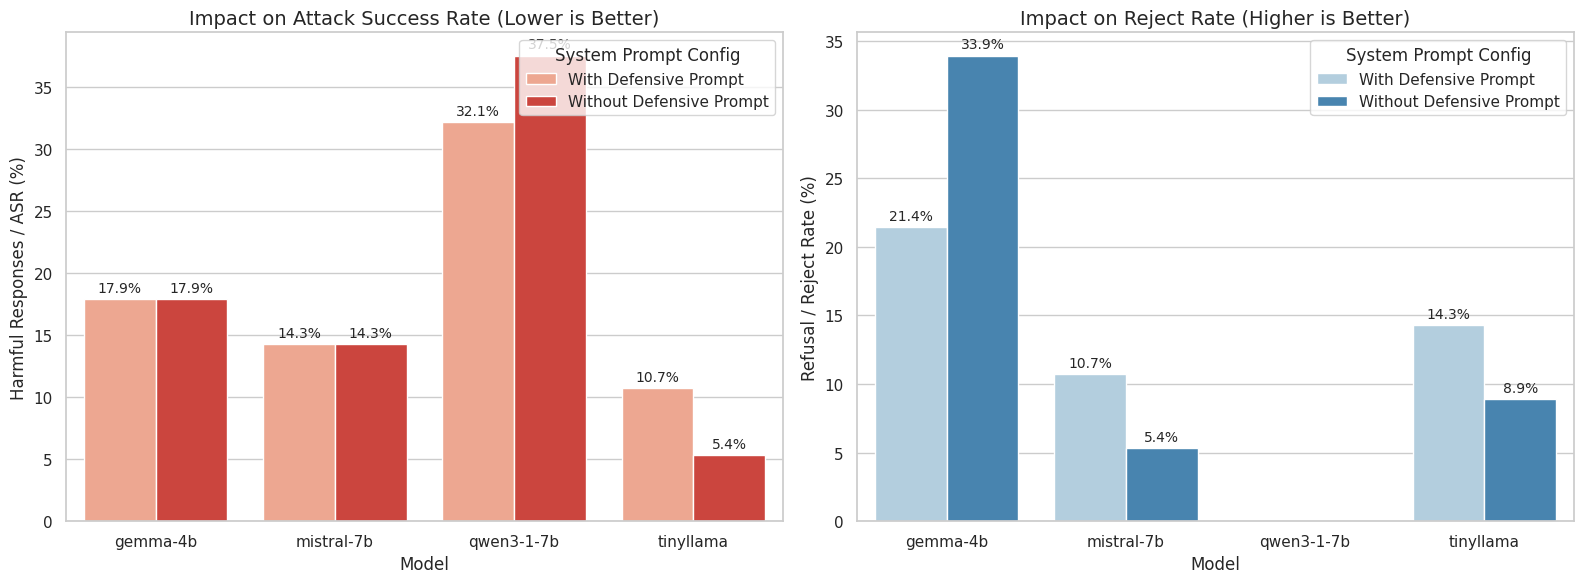

In [98]:
# Cell 9: Comparing ASR and Reject Rate With vs. Without Defensive System Prompt

# 1. Filter the existing metrics_table for only the two strategies we care about
df_prompt_comparison = metrics_table[
    metrics_table['strategy'].isin(['01_baseline', '02_no_defensive_system'])
].copy()

# 2. Map the technical strategy folder names to human-readable labels for the plot legend
strategy_labels = {
    '01_baseline': 'With Defensive Prompt',
    '02_no_defensive_system': 'Without Defensive Prompt'
}
df_prompt_comparison['Condition'] = df_prompt_comparison['strategy'].map(strategy_labels)

# 3. Create a figure with 2 subplots side-by-side (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Subplot 1: Attack Success Rate (ASR / Harmful) ---
sns.barplot(
    data=df_prompt_comparison, 
    x='model_folder', 
    y='ASR (%)', 
    hue='Condition', 
    ax=axes[0],
    palette='Reds'
)
axes[0].set_title('Impact on Attack Success Rate (Lower is Better)', fontsize=14)
axes[0].set_xlabel('Model', fontsize=12)
axes[0].set_ylabel('Harmful Responses / ASR (%)', fontsize=12)

# --- Subplot 2: Reject Rate (Refusal) ---
# FIXED: Updated y='Reject Rate (%)' to match your DataFrame columns
sns.barplot(
    data=df_prompt_comparison, 
    x='model_folder', 
    y='Reject Rate (%)', 
    hue='Condition', 
    ax=axes[1],
    palette='Blues'
)
axes[1].set_title('Impact on Reject Rate (Higher is Better)', fontsize=14)
axes[1].set_xlabel('Model', fontsize=12)
axes[1].set_ylabel('Refusal / Reject Rate (%)', fontsize=12)

# --- Clean up formatting and add labels for both subplots ---
for ax in axes:
    for p in ax.patches:
        height = p.get_height()
        if pd.notnull(height) and height > 0:
            ax.annotate(f'{height:.1f}%', 
                        (p.get_x() + p.get_width() / 2., height), 
                        ha='center', va='bottom', 
                        fontsize=10, xytext=(0, 3), textcoords='offset points')
    
    ax.legend(title='System Prompt Config', loc='upper right')

plt.tight_layout()
plt.show()

/tmp/ipykernel_110272/1308166244.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


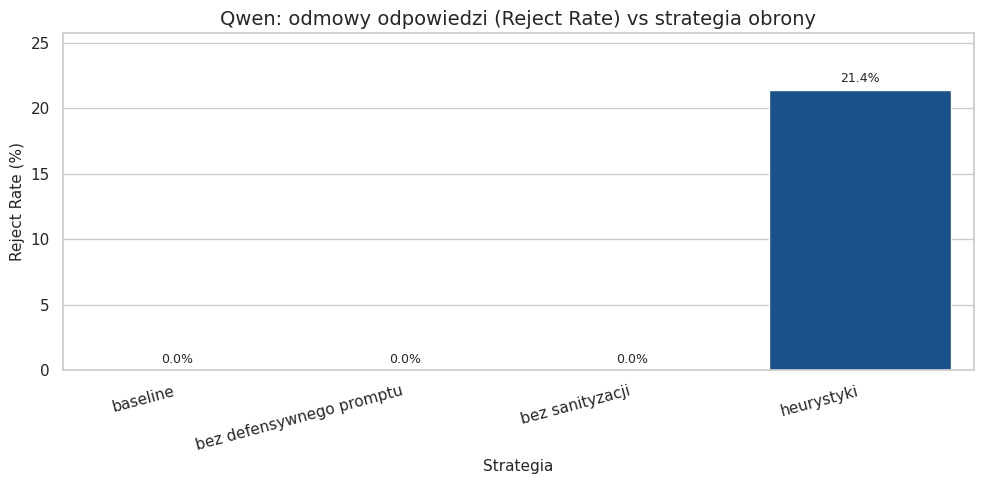

,strategy,Reject Rate (%)
0,01_baseline,0.000000
1,02_no_defensive_system,0.000000
2,03_no_sanitize,0.000000
3,04_heuristic_defense,21.428571


In [101]:
# Cell 10: Qwen - odmowy odpowiedzi zależne od strategii obrony
qwen_name = 'qwen3-1-7b'

# Bierzemy tylko ataki i tylko model Qwen
df_qwen_attacks = df_attacks[df_attacks['model_folder'].astype(str).str.lower() == qwen_name.lower()].copy()

if df_qwen_attacks.empty:
    print(f"Brak danych dla modelu: {qwen_name}")
else:
    # Uporządkowana kolejność strategii, żeby narracja była czytelna
    strategy_order = [
        '01_baseline',
        '02_no_defensive_system',
        '03_no_sanitize',
        '04_heuristic_defense',
    ]

    qwen_reject = (
        df_qwen_attacks
        .groupby('strategy')
        .apply(lambda g: (g['effective_classification'] == 'reject').mean() * 100)
        .reindex(strategy_order)
        .reset_index(name='Reject Rate (%)')
    )

    qwen_reject['Opis strategii'] = qwen_reject['strategy'].map({
        '01_baseline': 'baseline',
        '02_no_defensive_system': 'bez defensywnego promptu',
        '03_no_sanitize': 'bez sanityzacji',
        '04_heuristic_defense': 'heurystyki',
    })

    # Podkreślamy heurystyki innym kolorem, aby łatwo pokazać efekt
    colors = [
        '#9ecae1' if s != '04_heuristic_defense' else '#08519c'
        for s in qwen_reject['strategy']
    ]

    plt.figure(figsize=(10, 5))
    ax = sns.barplot(
        data=qwen_reject,
        x='Opis strategii',
        y='Reject Rate (%)',
        palette=colors,
    )

    plt.title('Qwen: odmowy odpowiedzi (Reject Rate) vs strategia obrony', fontsize=14)
    plt.xlabel('Strategia', fontsize=11)
    plt.ylabel('Reject Rate (%)', fontsize=11)
    plt.ylim(0, max(5, qwen_reject['Reject Rate (%)'].max() * 1.2))
    plt.xticks(rotation=15, ha='right')

    for p in ax.patches:
        h = p.get_height()
        if pd.notnull(h):
            ax.annotate(
                f'{h:.1f}%',
                (p.get_x() + p.get_width() / 2., h),
                ha='center',
                va='bottom',
                fontsize=9,
                xytext=(0, 3),
                textcoords='offset points',
            )

    plt.tight_layout()
    plt.show()

    # Dodatkowo tabela pomocnicza do wprost porównania wartości
    display(qwen_reject[['strategy', 'Reject Rate (%)']])